# 🐢 EPOCH Pilot Task Week 4
> 주제: 카드 이탈 데이터에 기반한 이탈 예측 모델 구축 및 고객 유형별 이탈 요인 분석

라이브러리 및 데이터 불러오기

In [ ]:
# 필요한 패키지
import joblib
from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

In [5]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/'

# 데이터 로드
X_train = pd.read_csv(f'{path}X_train_slim.csv')
y_train = pd.read_csv(f'{path}y_train.csv')

X_val = pd.read_csv(f'{path}X_valid_slim.csv')
y_val = pd.read_csv(f'{path}y_valid.csv')

X_test = pd.read_csv(f'{path}X_test_slim.csv')
y_test = pd.read_csv(f'{path}y_test.csv')

# 저장된 모델 로드
best_lgbm = joblib.load(f'{path}best_lgbm_model.pkl')

In [8]:
# 혹시 모르니 일단 원본 데이터도 불러와보자..
df = pd.read_csv('/content/drive/MyDrive/card_engineered.csv')

### TASK 1: Model Development

모델 제대로 불러와졌는지 확인

In [ ]:
# 불러온 모델 확인 
y_pred_proba = best_lgbm.predict_proba(X_val)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int) # 기본 임계값 0.5 적용

# 성능 확인
print(f"Validation ROC-AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")
print(f"Validation PR-AUC: {average_precision_score(y_val, y_pred_proba):.4f}")
print(classification_report(y_val, y_pred))

Validation ROC-AUC: 0.9924
Validation PR-AUC: 0.9684
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.92      0.90      0.91       326

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



보통 이탈자를 놓치는 비용이 훨씬 크기 때문에, 임계값을 낮춰서 '약간의 오탐지를 감수하더라도 최대한 많은 이탈자를 잡는 것'이 비즈니스적으로 훨씬 이득이다!

따라서 임계값 시뮬레이션을 통해 정밀도와 재현율의 변화를 확인해보자.

(✏️ 임계값이란?: 이탈인지 정상인지 분류하기 위한 커트라인. 만약 임계값이 0.4라면, 확률이 0.4보다 높으면 이탈 고객(1)으로 분류하고 낮다면 정상 고객(0)으로 분류한다.)

In [13]:
# 1. 모델의 예측 확률값 가져오기 (클래스 1일 확률)
y_val_probs = best_lgbm.predict_proba(X_val)[:, 1]

# 2. 임계값 후보군 설정 (0.05부터 0.95까지)
thresholds = np.arange(0.05, 1.0, 0.05)
results = []

for thres in thresholds:
    # 임계값 적용
    y_pred_temp = (y_val_probs >= thres).astype(int)
    
    # 지표 계산
    prec = precision_score(y_val, y_pred_temp)
    rec = recall_score(y_val, y_pred_temp)
    f1 = f1_score(y_val, y_pred_temp)
    
    results.append({'Threshold': thres, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

# 3. 결과 테이블 출력
df_results = pd.DataFrame(results)
print(df_results.sort_values(by='F1-Score', ascending=False)) # F1-Score 기준 내림차순

    Threshold  Precision    Recall  F1-Score
3        0.20   0.906061  0.917178  0.911585
11       0.60   0.926984  0.895706  0.911076
4        0.25   0.911043  0.911043  0.911043
10       0.55   0.924051  0.895706  0.909657
9        0.50   0.924051  0.895706  0.909657
2        0.15   0.893491  0.926380  0.909639
7        0.40   0.913313  0.904908  0.909091
6        0.35   0.913313  0.904908  0.909091
8        0.45   0.921136  0.895706  0.908243
1        0.10   0.879310  0.938650  0.908012
5        0.30   0.910494  0.904908  0.907692
12       0.65   0.929260  0.886503  0.907378
13       0.70   0.928571  0.877301  0.902208
16       0.85   0.940000  0.865031  0.900958
0        0.05   0.855956  0.947853  0.899563
14       0.75   0.928105  0.871166  0.898734
15       0.80   0.933775  0.865031  0.898089
17       0.90   0.955017  0.846626  0.897561
18       0.95   0.964664  0.837423  0.896552


결과 해석

- 특별한 비즈니스 제약이 없다면 0.20을 사용하는 것이 모델의 통계적 성능을 가장 잘 뽑아내는 선택

- (이탈 방지 비용) < (고객 한 명을 잃는 손실)이라면, 임계값을 0.05까지 낮추는 공격적인 전략이 유효

- 마케팅 예산이 매우 한정되어 있다면 임계값을 0.95까지 높이는 것이 좋다

어떤 임계값을 설정할지는 비즈니스 상황에 따라 다르다!

f1-score가 가장 높은 임계값 = 0.2로 결정하고, 테스트 데이터셋으로 모델의 성능 평가

--- [최종 결과] 임계값 0.2 적용 시 ---
Final Test ROC-AUC: 0.9898

[Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.88      0.90      0.89       325

    accuracy                           0.97      2026
   macro avg       0.93      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



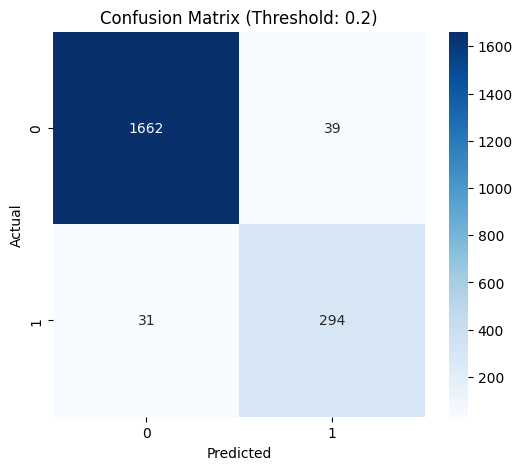

In [16]:
# 1. 테스트 데이터에 대해 이탈 확률(Probability) 예측
y_test_probs = best_lgbm.predict_proba(X_test)[:, 1]

# 2. 최적 임계값 0.2 적용
custom_threshold = 0.2
y_test_pred_final = (y_test_probs >= custom_threshold).astype(int)

# 3. 최종 성능 지표 출력
print(f"--- [최종 결과] 임계값 {custom_threshold} 적용 시 ---")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_test_probs):.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_test_pred_final))

# 4. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

이전 모델과 비교
* f1-score는 동일, precision 0.2 감소하고 recall 0.2 증가했다.
* 정상 고객 8명 덜 정확하게 분류했으나, 이탈 고객 8명을 더 잡아냈다.

카드 이탈 방지가 중요하므로 위의 모델을 최종 모델로 선정!

### TASK 2: 인사이트 및 개선 방향 

SHAP: 각 변수가 모델의 최종 예측 확률(이탈 확률)에 기여한 정도를 보여준다. 

**왜 이 고객이 이탈하는가**에 대한 비즈니스 인사이트를 도출해보자!

- X축 (SHAP Value): 0을 기준으로 오른쪽에 점이 많을수록 이탈 확률을 높이는 요인, 왼쪽은 정상 고객으로 판단하게 하는 요인

- 색상 (Feature Value): 빨간색일수록 해당 변수의 값이 높고, 파란색일수록 낮음을 의미

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


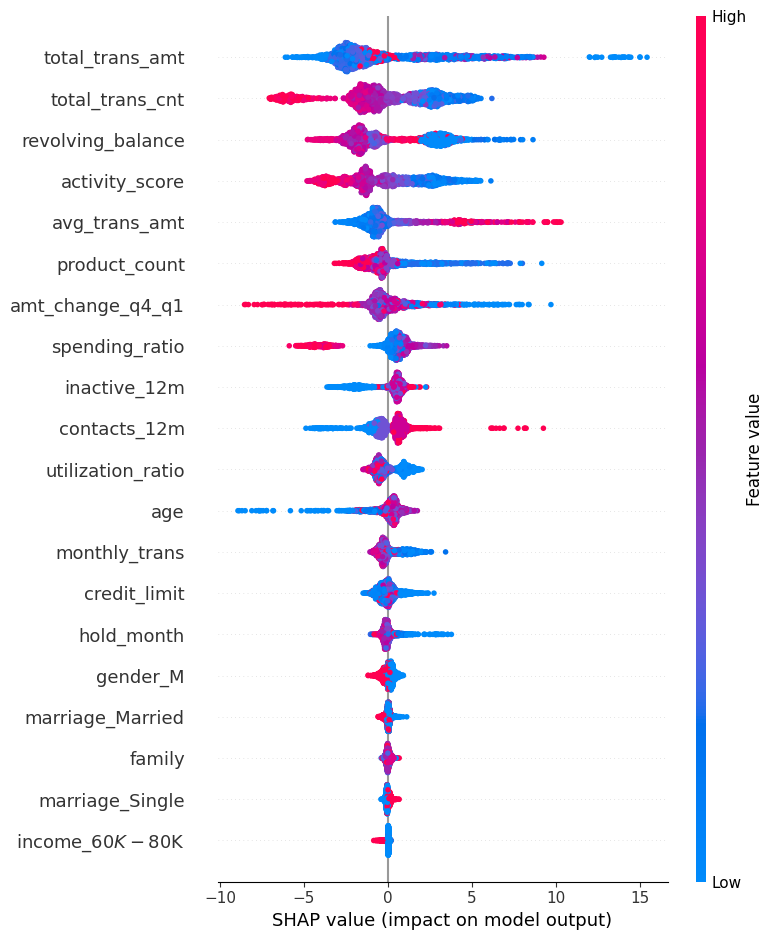

In [21]:
import shap

# 1. Explainer 및 shap_values 계산
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

shap_to_plot = shap_values

# 3. Summary Plot 출력
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test)

해석
* total_trans_amt(총 거래 금액)

거래 금액이 낮을수록(파란색) 이탈 확률을 높이는 경향이 있다.

* total_trans_cnt(총 거래 횟수)

거래 횟수가 많을수록(빨간색) 이탈 확률이 낮다.

* revolving_balance(리볼빙 잔액)

리볼빙 잔액이 높을수록 이탈 확률이 낮다.

* activity_score(활동지수)

활동성이 높을 수록 이탈 확률이 낮다.

* avg_trans_amt(평균 거래 금액)

평균 거래 금액이 높을수록 이탈 확률 높다. (+소액으로 자주 쓰는 고객이 더 유지?) 

* product_count(상품 가입 개수)

상품 많이 보유하고 있을 수록 이탈 확률이 낮다.

* amt_change_q4_q1

최근 소비가 감소한 것은 강력한 이탈 신호가 된다.

* contacts_12m(12개월간 고객센터 접촉 횟수)

고객의 문의가 많을수록 이탈 확률이 높아진다.

* inactive_12m(비활성 기간)

비활성 기간이 길 수록 이탈 확률 높아진다.

* 인구통계학적 변수들(age, gender, marriage, income)은 중요도가 대부분 낮게 나타난다. 

***

#### 📍 요약 및 시사점

##### ✅ **활동성 지표가 핵심** 

total_trans_cnt, total_trans_amt, activity_score 같은 활동 관련 변수들이 최상단에 위치한다. 고객이 얼마나 자주, 많이 서비스를 이용하는지가 예측의 가장 중요한 척도가 된다.

❗️ 부정적 신호 (High Risk 고객 특징)
- 거래 횟수 ↓ (total_trans_cnt ↓)
- 거래 금액 ↓ (total_trans_amt ↓)
- 최근 소비 감소 (amt_change_q4_q1 ↓)
- 고객센터 접촉 ↑ (contacts_12m ↑)
- 비활성 기간 ↑ (inactive_12m ↑)

즉, “사용이 줄고 + 문제 접촉이 증가하는 고객” = 거의 이탈 직전


##### ✅ **평균 거래금액의 해석**

avg_trans_amt가 높을수록 오히려 이탈 방향으로 작용했다.

“큰 금액을 가끔 쓰는 고객”보다 “작게라도 자주 쓰는 고객”이 더 안정적!

##### ✅ **인구통계학적 변수의 낮은 영향력**  

차트 하단에 위치한 gender, marriage, income 등은 모델의 최종 판단에 미치는 영향이 상대적으로 매우 적다. 즉, "누구인가"보다 **"어떻게 행동하는가"**가 예측에 훨씬 중요하다.

> 결론: 카드 이탈은 고객 특성이 아닌 '사용 감소 패턴 + 불만'에서 발생한다

갑자기 떠나는 것이 아니라, 사용 감소 > 비활성화 > 불만 신호 증가라는 패턴을 통해 사전에 식별 가능하다!

***

#### ⊕ 향후 개선 방향

##### 1️⃣ 시간 흐름을 반영한 분석
**amt_change_q4_q1(전분기 대비 금액 변화)** 변수가 상위 중요도를 보였다.

이탈 예측에 있어서 '추세(Trend)'가 중요하다는 것.

즉, “사용이 증가하고 있는가, 감소하고 있는가”라는 방향성 자체가 중요한 신호이다.

예를 들어, 현재 거래액이 높은 고객이라도 최근 사용량이 지속적으로 감소하고 있다면 이는 강력한 이탈의 조기 경보 신호로 작용할 수 있다.

-> 단순히 현재 상태가 아닌 변화의 방향성을 파악할 수 있는 파생 변수(예: 최근 기간 대비 거래금액/거래횟수 변화율)를 활용해본다던가, 시계열 특징을 추출한다면? 

##### 2️⃣ 모델 성능 개선

현재는 Random Forest, XGBoost, LightGBM 중 하나의 모델을 선택하여 활용하였으나,
각 모델의 장점을 결합하는 **앙상블 기법(예: Stacking)**을 적용할 경우 추가적인 성능 향상을 기대할 수 있을 것.

##### 3️⃣ 세그먼트 기반 분석
모든 고객을 하나로 보는 건 한계가 있다.

실제 데이터에서도 education, marriage, 부양 가족 수(family) 등 인구통계학적 변수에 따라 이탈률의 차이가 존재하는 것으로 확인되었다.

-> 인구통계학적 변수 기반으로 고객을 세분화해서 각 세그먼트별로 별도의 분석 또는 모델링을 수행한다면?